#🛠️ Preparación de los Datos

##Extracción del Archivo Tratado

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
datos = pd.read_csv('/content/datos_tratados.csv')
datos.head ()

,Customer_ID,Churn,Gender,Senior_Citizen,Partner,Dependents,Ternure,Phone_Service,Multiple_Lines,Internet_Service,...,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Charges_Monthly,Charges_Total
0,0002-ORFBO,0,0,0,1,1,9,1,0,1,...,1,0,1,1,0,1,1,0,65.6,593.30
1,0003-MKNFE,0,1,0,0,0,9,1,1,1,...,0,0,0,0,1,0,0,0,59.9,542.40
2,0004-TLHLJ,1,1,0,0,0,4,1,0,2,...,0,1,0,0,0,0,1,1,73.9,280.85
3,0011-IGKFF,1,1,1,1,0,13,1,0,2,...,1,1,0,1,1,0,1,1,98.0,1237.85
4,0013-EXCHZ,1,0,1,1,0,3,1,0,2,...,0,0,1,1,0,0,1,0,83.9,267.40


In [3]:
datos.columns

Index(['Customer_ID', 'Churn', 'Gender', 'Senior_Citizen', 'Partner',
       'Dependents', 'Ternure', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
       'Contract', 'Paperless_Billing', 'Payment_Method', 'Charges_Monthly',
       'Charges_Total'],
      dtype='object')

In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        7032 non-null   object 
 1   Churn              7032 non-null   int64  
 2   Gender             7032 non-null   int64  
 3   Senior_Citizen     7032 non-null   int64  
 4   Partner            7032 non-null   int64  
 5   Dependents         7032 non-null   int64  
 6   Ternure            7032 non-null   int64  
 7   Phone_Service      7032 non-null   int64  
 8   Multiple_Lines     7032 non-null   int64  
 9   Internet_Service   7032 non-null   int64  
 10  Online_Security    7032 non-null   int64  
 11  Online_Backup      7032 non-null   int64  
 12  Device_Protection  7032 non-null   int64  
 13  Tech_Support       7032 non-null   int64  
 14  Streaming_TV       7032 non-null   int64  
 15  Streaming_Movies   7032 non-null   int64  
 16  Contract           7032 

Datos únicos por columna:

    Customer_ID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB' '9995-HOTOH']
    Churn: {'No': 0, 'Yes': 1}
    Gender: {'Female': 0, 'Male': 1}
    Senior_Citizen: {'No': 0, 'Yes': 1}
    Partner: {'No': 0, 'Yes': 1}
    Dependents: {'No': 0, 'Yes': 1}
    Ternure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42 0]
    Phone_Service: {'No': 0, 'Yes': 1}
    Multiple_Lines: {'No': 0, 'Yes': 1, 'No phone service': 2}
    Internet_Service: {'No': 0, 'DSL': 1, 'Fiber optic': 2}
    Online_Security: {'No': 0, 'Yes': 1, 'No internet service': 2}
    Online_Backup: {'No': 0, 'Yes': 1, 'No internet service': 2}
    Device_Protection: {'No': 0, 'Yes': 1, 'No internet service': 2}
    Tech_Support: {'No': 0, 'Yes': 1, 'No internet service': 2}
    Streaming_TV: {'No': 0, 'Yes': 1, 'No internet service': 2}
    Streaming_Movies: {'No': 0, 'Yes': 1, 'No internet service': 2}
    Contract: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    Paperless_Billing: {'No': 0, 'Yes': 1}
    Payment_Method: {'Mailed check': 0, 'Electronic check': 1, 'Credit card (automatic)': 2,'Bank transfer (automatic)': 3}
    Charges_Monthly: [65.6  59.9  73.9  ... 91.75 68.8  67.85]
    Charges_Total: ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']

In [5]:
#Unificamos respuestas con triple categoría que son casi lo mismo
cols_to_fix = ['Multiple_Lines', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies']

#Reemplazamos las variables de 'No internet service': 2 por 'No': 0
for  col in cols_to_fix:
  datos[col] = datos[col].replace({2:0})

In [6]:
#Definimos función para enlistar los valores únicas de cada columna
def valores_unicos(df, columnas):
    for col in columnas:
        print(f'{col}: {df[col].unique()}')

In [7]:
#Utilizamos la función que definimos
valores_unicos(datos,cols_to_fix)

Multiple_Lines: [0 1]
Online_Security: [0 1]
Online_Backup: [1 0]
Device_Protection: [0 1]
Tech_Support: [1 0]
Streaming_TV: [1 0]
Streaming_Movies: [0 1]


In [8]:
datos.head(10)

,Customer_ID,Churn,Gender,Senior_Citizen,Partner,Dependents,Ternure,Phone_Service,Multiple_Lines,Internet_Service,...,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Charges_Monthly,Charges_Total
0,0002-ORFBO,0,0,0,1,1,9,1,0,1,...,1,0,1,1,0,1,1,0,65.60,593.30
1,0003-MKNFE,0,1,0,0,0,9,1,1,1,...,0,0,0,0,1,0,0,0,59.90,542.40
2,0004-TLHLJ,1,1,0,0,0,4,1,0,2,...,0,1,0,0,0,0,1,1,73.90,280.85
3,0011-IGKFF,1,1,1,1,0,13,1,0,2,...,1,1,0,1,1,0,1,1,98.00,1237.85
4,0013-EXCHZ,1,0,1,1,0,3,1,0,2,...,0,0,1,1,0,0,1,0,83.90,267.40
5,0013-MHZWF,0,0,0,0,1,9,1,0,1,...,0,0,1,1,1,0,1,2,69.40,571.45
6,0013-SMEOE,0,0,1,1,0,71,1,0,2,...,1,1,1,1,1,2,1,3,109.70,7904.25
7,0014-BMAQU,0,1,0,1,0,63,1,1,2,...,0,0,1,0,0,2,1,2,84.65,5377.80
8,0015-UOCOJ,0,0,1,0,0,7,1,0,1,...,0,0,0,0,0,0,1,1,48.20,340.35
9,0016-QLJIS,0,0,0,1,1,65,1,1,1,...,1,1,1,1,1,2,1,0,90.45,5957.90


In [9]:
#Verificamos nuevamente que no haya datos nulos
datos.isnull().sum()

,0
Customer_ID,0
Churn,0
Gender,0
Senior_Citizen,0
Partner,0
Dependents,0
Ternure,0
Phone_Service,0
Multiple_Lines,0
Internet_Service,0


##Eliminación de columnas irrelevantes

In [10]:
datos = datos.drop(columns='Customer_ID')

##Encoding

Normalmente, si los datos ya están codificados (como en mi caso) No se necesitaría. Sin embargo, hay algunas columnas que son ternarias o cuaternarias categóricas nominales sin orden real:
   
    Internet_Service: {'No': 0, 'DSL': 1, 'Fiber optic': 2}
    Contract: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
    Payment_Method: {'Mailed check': 0, 'Electronic check': 1, 'Credit card (automatic)': 2,'Bank transfer (automatic)': 3}

lo que podría provocar que el modelo le asocie un orden implícito y no queremos eso.

In [11]:
#Utilizamos el método get_dummies
datos = pd.get_dummies(data= datos, columns=['Internet_Service', 'Contract', 'Payment_Method'], dtype=int)
datos.head(10)

,Churn,Gender,Senior_Citizen,Partner,Dependents,Ternure,Phone_Service,Multiple_Lines,Online_Security,Online_Backup,...,Internet_Service_0,Internet_Service_1,Internet_Service_2,Contract_0,Contract_1,Contract_2,Payment_Method_0,Payment_Method_1,Payment_Method_2,Payment_Method_3
0,0,0,0,1,1,9,1,0,0,1,...,0,1,0,0,1,0,1,0,0,0
1,0,1,0,0,0,9,1,1,0,0,...,0,1,0,1,0,0,1,0,0,0
2,1,1,0,0,0,4,1,0,0,0,...,0,0,1,1,0,0,0,1,0,0
3,1,1,1,1,0,13,1,0,0,1,...,0,0,1,1,0,0,0,1,0,0
4,1,0,1,1,0,3,1,0,0,0,...,0,0,1,1,0,0,1,0,0,0
5,0,0,0,0,1,9,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
6,0,0,1,1,0,71,1,0,1,1,...,0,0,1,0,0,1,0,0,0,1
7,0,1,0,1,0,63,1,1,1,0,...,0,0,1,0,0,1,0,0,1,0
8,0,0,1,0,0,7,1,0,1,0,...,0,1,0,1,0,0,0,1,0,0
9,0,0,0,1,1,65,1,1,1,1,...,0,1,0,0,0,1,1,0,0,0


In [12]:
#Renombramos las nuevas columnas

datos.rename(columns={
    'Internet_Service_0':'Internet_Service', 'Internet_Service_1':'Internet_DSL', 'Internet_Service_2':'Internet_FiberOptic',
    'Contract_0':'Contract_Monthly', 'Contract_1':'Contract_OneYear', 'Contract_2':'Contract_TwoYear',
    'Payment_Method_0':'Payment_Mailed_Check', 'Payment_Method_1':'Payment_Electronic_Check', 'Payment_Method_2':'Payment_Credit_Card', 'Payment_Method_3':'Payment_Bank_Transfer'
    },
             inplace= True)
datos.columns

Index(['Churn', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Ternure',
       'Phone_Service', 'Multiple_Lines', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
       'Paperless_Billing', 'Charges_Monthly', 'Charges_Total',
       'Internet_Service', 'Internet_DSL', 'Internet_FiberOptic',
       'Contract_Monthly', 'Contract_OneYear', 'Contract_TwoYear',
       'Payment_Mailed_Check', 'Payment_Electronic_Check',
       'Payment_Credit_Card', 'Payment_Bank_Transfer'],
      dtype='object')

In [13]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Churn                     7032 non-null   int64  
 1   Gender                    7032 non-null   int64  
 2   Senior_Citizen            7032 non-null   int64  
 3   Partner                   7032 non-null   int64  
 4   Dependents                7032 non-null   int64  
 5   Ternure                   7032 non-null   int64  
 6   Phone_Service             7032 non-null   int64  
 7   Multiple_Lines            7032 non-null   int64  
 8   Online_Security           7032 non-null   int64  
 9   Online_Backup             7032 non-null   int64  
 10  Device_Protection         7032 non-null   int64  
 11  Tech_Support              7032 non-null   int64  
 12  Streaming_TV              7032 non-null   int64  
 13  Streaming_Movies          7032 non-null   int64  
 14  Paperles

##Verificación de la Proporción de Cancelación (Churn)

In [14]:
datos['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [15]:
datos['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


##Normalización o Estandarización

In [16]:
from sklearn.preprocessing import MinMaxScaler

normalizacion = MinMaxScaler()
datos_normalizado = normalizacion.fit_transform(datos)
pd.DataFrame(datos_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,0.0,0.0,0.0,1.0,1.0,0.112676,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.112676,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.042254,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,1.0,1.0,1.0,0.0,0.169014,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,1.0,1.0,0.0,0.028169,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,0.0,0.0,0.169014,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
7028,1.0,1.0,0.0,1.0,0.0,0.295775,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7029,0.0,1.0,0.0,0.0,0.0,0.014085,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
7030,0.0,1.0,0.0,1.0,1.0,0.929577,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


La normalización es un paso crítico cuando se trabaja con algoritmos que "miden" distancias o que intentan encontrar el mínimo de una función de error. Para entender por qué evita el sesgo, hay que visualizar cómo ven los datos estos modelos.

Imagina que estás comparando dos clientes en tu dataset de TelecomX:

* Cliente A: Antigüedad (Ternure) de 70 meses y Cargos Totales (Charges_Total) de 100 USD.

* Cliente B: Antigüedad de 10 meses y Cargos Totales de 8000 USD.

**1. El Sesgo en Modelos de Distancia (ej. KNN o SVM)**

Algoritmos como K-Nearest Neighbors (KNN) calculan la "cercanía" entre puntos usando la distancia euclidiana. La fórmula es similar al teorema de Pitágoras:

    d(p,q)=((p1​−q1​)²+(p2​−q2​)²​)^½

Si no normalizas, la diferencia en Charges_Total (8000−100=7900) eclipsará totalmente la diferencia en Ternure (70−10=60). Al elevar al cuadrado, la magnitud de los cargos será millones de veces superior. El modelo pensará que la antigüedad no importa, simplemente porque sus números son más pequeños, aunque un cambio de 1 a 70 meses sea mucho más significativo para el negocio que una variación de unos pocos dólares.

**2. El Sesgo en Optimización (ej. Regresión Logística o Redes Neuronales)**

Estos modelos utilizan el Descenso de Gradiente para encontrar los mejores pesos (w) para cada variable.

*  Si una variable tiene un rango enorme (como Charges_Total), su peso asociado tendrá que ser minúsculo para no "romper" la ecuación.

*  Esto crea una superficie de error muy alargada y estrecha (como un desfiladero).

* El algoritmo de optimización empezará a oscilar violentamente de un lado a otro, tardando mucho más en converger o incluso perdiéndose sin encontrar la solución óptima.

¿Cómo lo soluciona la Normalización?

Al aplicar técnicas como Min-Max Scaling o StandardScaler, llevas todas las variables a una escala común (por ejemplo, entre 0 y 1).

*  Igualdad de condiciones: Ahora, una variación del 10% en la antigüedad pesa exactamente lo mismo que una variación del 10% en los cargos totales.

* Convergencia rápida: El descenso de gradiente se vuelve mucho más estable porque la "superficie" por la que viaja es más simétrica.

#🎯 Correlación y Selección de Variables

###Matriz de Correlación entre variables numéricas

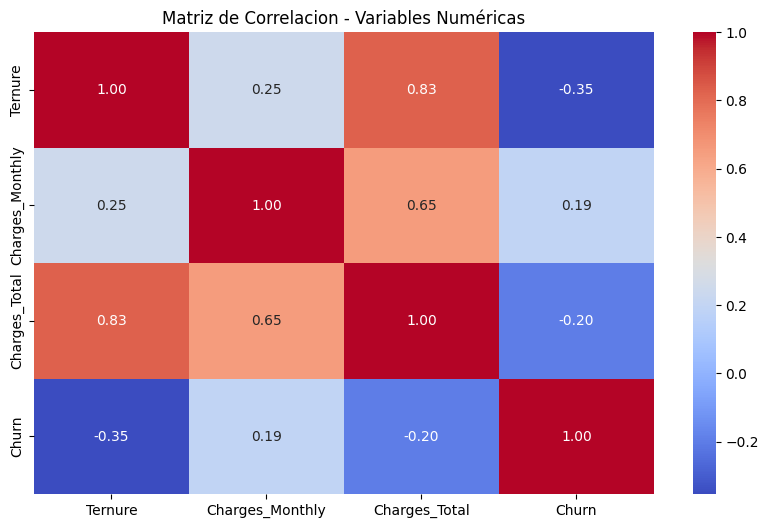

In [17]:
datos_numeric = datos[['Ternure','Charges_Monthly','Charges_Total', 'Churn']]

corr_matrix = datos_numeric.corr()

#Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion - Variables Numéricas')
plt.show()

valores que se consideran en alto riesgo de multicolinealidad al efectuar correlaciones:

-Cuando es < 0.5: (baja correlación, normalmente no hay problema).

-Cuando es >= 0.5, < 0.7: (riesgo moderado, vigilar, posible multicolinealidad).

-Cuando es >= 0.7, < 0.9: (alta correlación, posible multicolinealidad).

-Cuando es >= 0.9: (muy alta correlación, muy alto riesgo de multicolinealidad).

-se empieza a revisar seriamente cuando es > a 0.8 -> aporta información redundante.

Por eso debíamos eliminar Charges Total


Entre Charges Total y Ternure elijo: Ternure. Ya que no tiene tanta correlación con todas tampoco.

###Matriz de Correlación para todas las variables

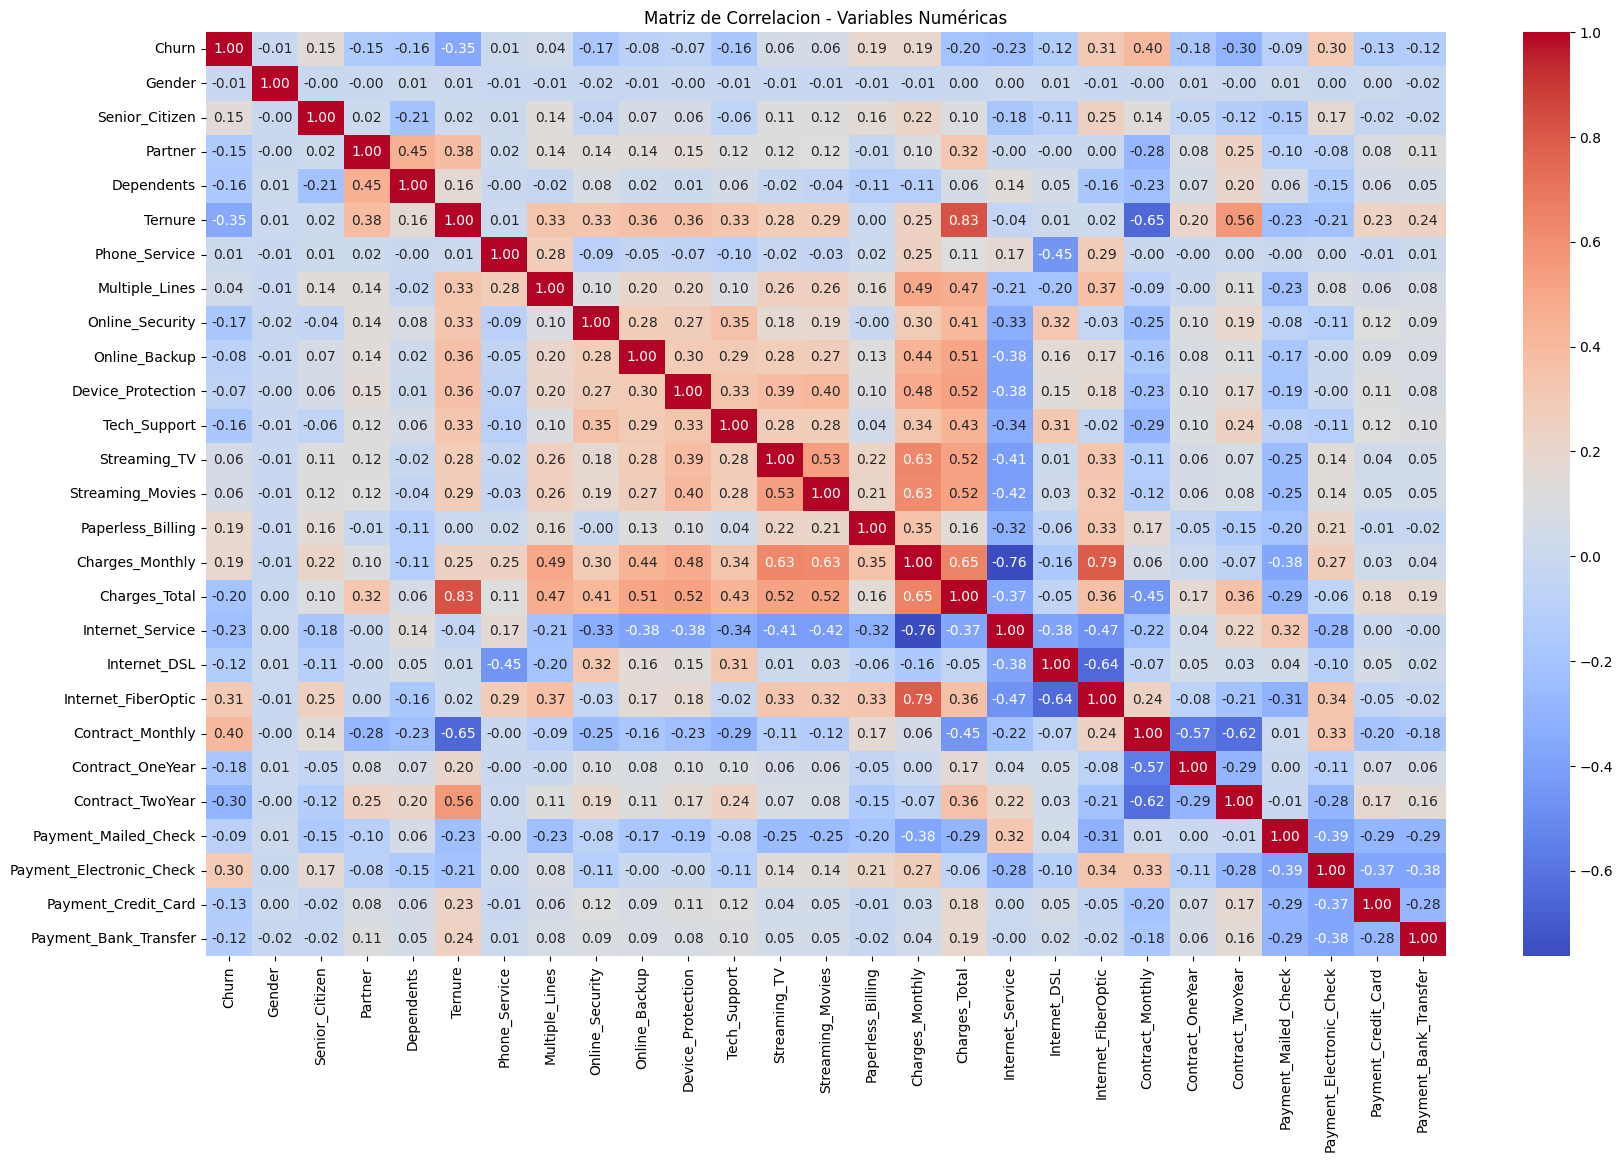

In [18]:
datos_numeric = datos.select_dtypes(include=['int64','float64'])

corr_matrix = datos_numeric.corr()

#Visualizar heatmap
plt.figure(figsize=(20,12))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion - Variables Numéricas')
plt.show()

###Análisis de Churn por variables categóricas

####Análisis de Churn por Método de chi cuadrada

In [19]:
from sklearn.feature_selection import chi2


#Separar X e y
X_cat = datos.drop(columns=['Churn'])
y = datos['Churn']

#Aplicar test de Chi Cuadrada
chi_scores, p_values = chi2(X_cat,y)

#Crear DataFrame con las columnas
chi_df = pd.DataFrame({
    'Variable': X_cat.columns,
    'Chi2 Score': chi_scores,
    'p-value': p_values
})

#Ordenar por importancia
chi_df = chi_df.sort_values(by='Chi2 Score',  ascending= False)

chi_df

,Variable,Chi2 Score,p-value
15,Charges_Total,629630.810349,0.000000e+00
4,Ternure,16377.328093,0.000000e+00
14,Charges_Monthly,3653.074681,0.000000e+00
19,Contract_Monthly,516.714004,2.195119e-114
21,Contract_TwoYear,486.223101,9.454286e-108
23,Payment_Electronic_Check,424.113152,3.105849e-94
18,Internet_FiberOptic,372.082851,6.587130e-83
16,Internet_Service,285.475152,4.814000e-64
20,Contract_OneYear,176.608724,2.666317e-40
7,Online_Security,147.165601,7.219883e-34


ChiScore: a más alto, más asociación. Las que están por menos de 20 son las que podemos quitar.
p value debe ser menor de 0.05 para

##Eliminación de Columnas Irrelevantes

In [20]:
df = datos.drop(columns= ['Gender', 'Phone_Service','Multiple_Lines','Streaming_TV', 'Streaming_Movies', 'Charges_Total'])
df.head(2)

,Churn,Senior_Citizen,Partner,Dependents,Ternure,Online_Security,Online_Backup,Device_Protection,Tech_Support,Paperless_Billing,...,Internet_Service,Internet_DSL,Internet_FiberOptic,Contract_Monthly,Contract_OneYear,Contract_TwoYear,Payment_Mailed_Check,Payment_Electronic_Check,Payment_Credit_Card,Payment_Bank_Transfer
0,0,0,1,1,9,0,1,0,1,1,...,0,1,0,0,1,0,1,0,0,0
1,0,0,0,0,9,0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0


In [21]:
#Utilizamos la función que definimos de valores únicos por columna
valores_unicos(df,df.columns)

Churn: [0 1]
Senior_Citizen: [0 1]
Partner: [1 0]
Dependents: [1 0]
Ternure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
Online_Security: [0 1]
Online_Backup: [1 0]
Device_Protection: [0 1]
Tech_Support: [1 0]
Paperless_Billing: [1 0]
Charges_Monthly: [65.6  59.9  73.9  ... 91.75 68.8  67.85]
Internet_Service: [0 1]
Internet_DSL: [1 0]
Internet_FiberOptic: [0 1]
Contract_Monthly: [0 1]
Contract_OneYear: [1 0]
Contract_TwoYear: [0 1]
Payment_Mailed_Check: [1 0]
Payment_Electronic_Check: [0 1]
Payment_Credit_Card: [0 1]
Payment_Bank_Transfer: [0 1]


##Análisis Dirigido
Investiga cómo variables específicas se relacionan con la cancelación, tales como:

    Tiempo de contrato × Cancelación

    Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [22]:
import matplotlib.pyplot as plt

In [23]:
continuan = df.groupby('Churn').get_group(0)
continuan.sample(5)

,Churn,Senior_Citizen,Partner,Dependents,Ternure,Online_Security,Online_Backup,Device_Protection,Tech_Support,Paperless_Billing,...,Internet_Service,Internet_DSL,Internet_FiberOptic,Contract_Monthly,Contract_OneYear,Contract_TwoYear,Payment_Mailed_Check,Payment_Electronic_Check,Payment_Credit_Card,Payment_Bank_Transfer
5532,0,0,1,1,52,1,0,1,1,1,...,0,0,1,1,0,0,0,0,0,1
1914,0,0,0,0,1,1,1,0,1,1,...,0,0,1,1,0,0,1,0,0,0
536,0,0,0,0,16,0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
6508,0,0,1,1,48,0,0,0,0,0,...,1,0,0,0,0,1,1,0,0,0
6289,0,1,1,0,34,0,0,0,0,0,...,0,0,1,1,0,0,0,0,1,0


In [24]:
evasores = df.groupby('Churn').get_group(1)
evasores.sample(5)

,Churn,Senior_Citizen,Partner,Dependents,Ternure,Online_Security,Online_Backup,Device_Protection,Tech_Support,Paperless_Billing,...,Internet_Service,Internet_DSL,Internet_FiberOptic,Contract_Monthly,Contract_OneYear,Contract_TwoYear,Payment_Mailed_Check,Payment_Electronic_Check,Payment_Credit_Card,Payment_Bank_Transfer
2526,1,0,0,0,9,0,0,0,0,0,...,0,0,1,1,0,0,0,1,0,0
1103,1,0,0,0,1,0,0,0,0,0,...,0,1,0,1,0,0,0,1,0,0
5878,1,0,0,0,1,0,0,1,0,1,...,0,1,0,1,0,0,1,0,0,0
6788,1,0,1,1,30,0,0,1,0,1,...,0,0,1,1,0,0,0,1,0,0
5115,1,0,0,0,10,0,0,1,0,1,...,0,0,1,1,0,0,0,1,0,0


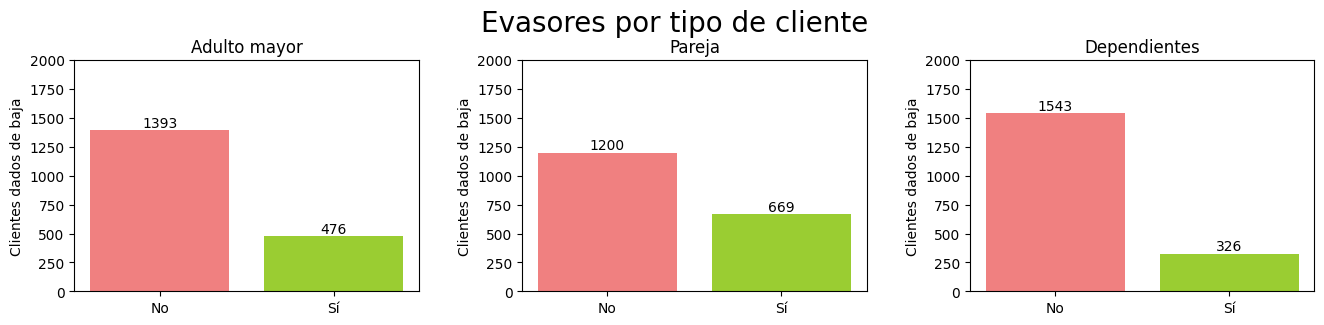

In [25]:
fig, axs = plt.subplots(1,3,figsize=(16,3))
fig.subplots_adjust(hspace=0.5,wspace=0.3)
fig.suptitle('Evasores por tipo de cliente', fontsize=20, y=1.05)

viejitos = evasores['Senior_Citizen'].value_counts().sort_index()
parejas = evasores['Partner'].value_counts().sort_index()
dependientes = evasores['Dependents'].value_counts().sort_index()

axs[0].bar(viejitos.index, viejitos.values, color=['lightcoral','yellowgreen'])
axs[0].set_title('Adulto mayor')

axs[1].bar(parejas.index, parejas.values, color=['lightcoral','yellowgreen'])
axs[1].set_title('Pareja')

axs[2].bar(dependientes.index, dependientes.values, color=['lightcoral','yellowgreen'])
axs[2].set_title('Dependientes')

ymin = 0
ymax = 2000

#Iteración para establecer los mismos valores de eje Y
for ax in axs.ravel():
  ax.set_ylim(ymin, ymax)

#Iteración para establecer los mismos Etiquetados
for ax in axs.flat:
  ax.set_xlabel('')
  ax.set_ylabel('Clientes dados de baja')
  ax.set_xticks([0, 1])
  ax.set_xticklabels(['No', 'Sí'])

#Iteración para las etiquetas arriba de las barras
tipo_cliente = [viejitos, parejas, dependientes]

for ax, serie in zip(axs.ravel(), tipo_cliente):
    for i, valor in enumerate(serie.values):
        ax.text(i, valor, str(valor), ha='center', va='bottom', fontsize=10)

#Almacenando el gráfico
fig.savefig('/content/tipo_cliente.png',
            transparent=False,dpi=300,bbox_inches='tight')

plt.show()

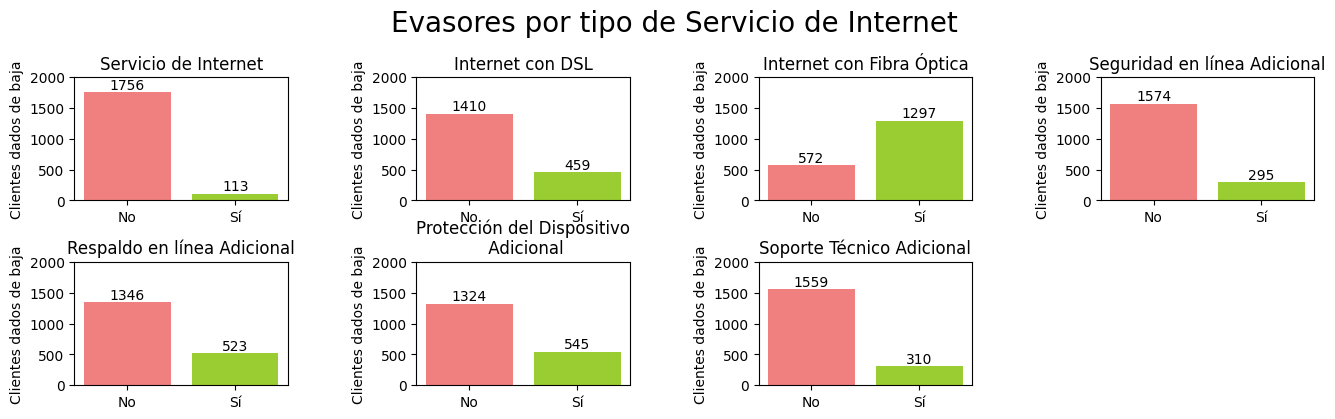

In [26]:
fig, axs = plt.subplots(2,4,figsize=(16,4))
fig.subplots_adjust(hspace=0.5,wspace=0.6)
fig.suptitle('Evasores por tipo de Servicio de Internet', fontsize=20, y=1.05)

servicio_internet = evasores['Internet_Service'].value_counts().sort_index()
internet_DSL = evasores['Internet_DSL'].value_counts().sort_index()
internet_FO = evasores['Internet_FiberOptic'].value_counts().sort_index()
seguridad = evasores['Online_Security'].value_counts().sort_index()
respaldo = evasores['Online_Backup'].value_counts().sort_index()
proteccion = evasores['Device_Protection'].value_counts().sort_index()
soporte = evasores['Tech_Support'].value_counts().sort_index()

axs[0,0].bar(servicio_internet.index, servicio_internet.values, color=['lightcoral','yellowgreen'])
axs[0,0].set_title('Servicio de Internet')

axs[0,1].bar(internet_DSL.index, internet_DSL.values, color=['lightcoral','yellowgreen'])
axs[0,1].set_title('Internet con DSL')

axs[0,2].bar(internet_FO.index, internet_FO.values, color=['lightcoral','yellowgreen'])
axs[0,2].set_title('Internet con Fibra Óptica')

axs[0,3].bar(seguridad.index, seguridad.values, color=['lightcoral','yellowgreen'])
axs[0,3].set_title('Seguridad en línea Adicional')

axs[1,0].bar(respaldo.index, respaldo.values, color=['lightcoral','yellowgreen'])
axs[1,0].set_title('Respaldo en línea Adicional')

axs[1,1].bar(proteccion.index, proteccion.values, color=['lightcoral','yellowgreen'])
axs[1,1].set_title('Protección del Dispositivo\n Adicional')

axs[1,2].bar(soporte.index, soporte.values, color=['lightcoral','yellowgreen'])
axs[1,2].set_title('Soporte Técnico Adicional')

ymin = 0
ymax = 2000

#Iteración para establecer los mismos valores de eje Y
for ax in axs.ravel():
  ax.set_ylim(ymin, ymax)

#Iteración para establecer los mismos Etiquetados
for ax in axs.flat:
  ax.set_xlabel('')
  ax.set_ylabel('Clientes dados de baja')
  ax.set_xticks([0, 1])
  ax.set_xticklabels(['No', 'Sí'])

#Iteración para las etiquetas arriba de las barras
tipo_cliente = [servicio_internet, internet_DSL, internet_FO, seguridad, respaldo, proteccion, soporte]

for ax, serie in zip(axs.ravel(), tipo_cliente):
    for i, valor in enumerate(serie.values):
        ax.text(i, valor, str(valor), ha='center', va='bottom', fontsize=10)

#Oculto el último gráfico
axs[1,3].axis('off')

#Almacenando el gráfico
fig.savefig('/content/servicio_internet.png',
            transparent=False,dpi=300,bbox_inches='tight')

plt.show()

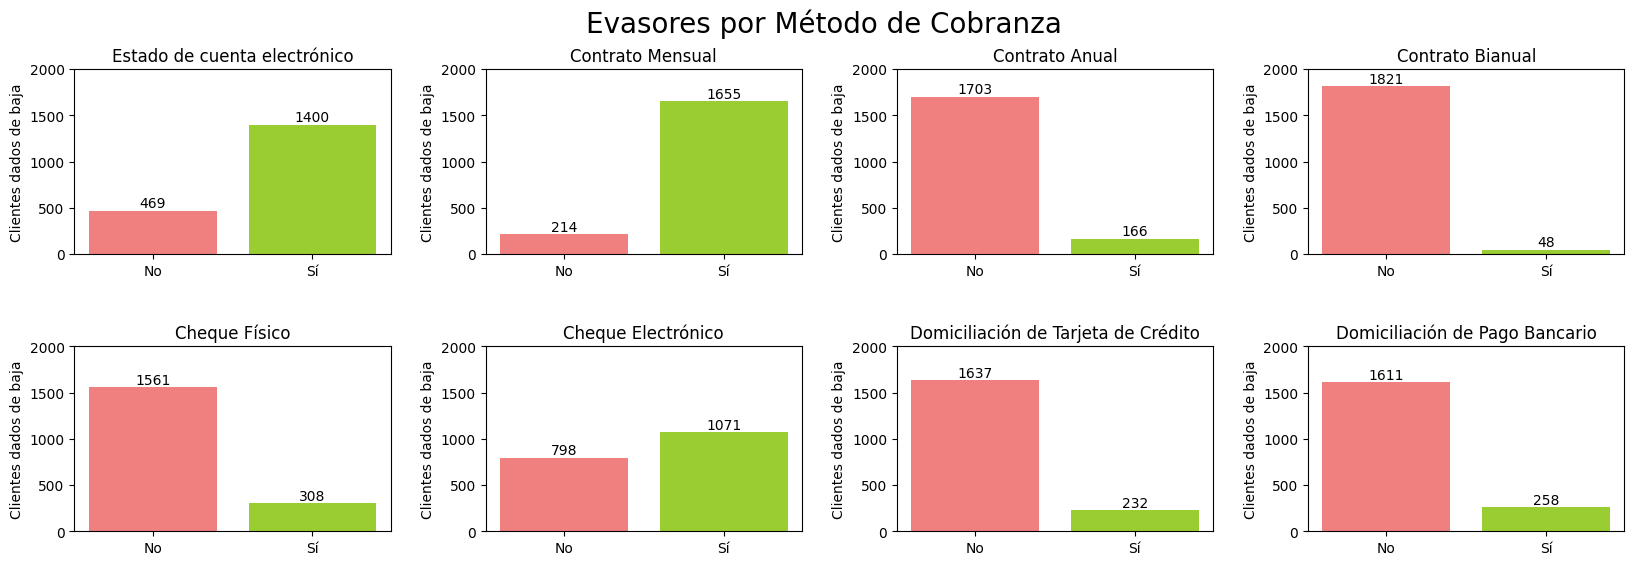

In [27]:
fig, axs = plt.subplots(2,4,figsize=(20,6))
fig.subplots_adjust(hspace=0.5,wspace=0.3)
fig.suptitle('Evasores por Método de Cobranza', fontsize=20)

electronico = evasores['Paperless_Billing'].value_counts().sort_index()

contrato_mensual = evasores['Contract_Monthly'].value_counts().sort_index()
contrato_anual = evasores['Contract_OneYear'].value_counts().sort_index()
contrato_bianual = evasores['Contract_TwoYear'].value_counts().sort_index()

pago_cheque_fisico = evasores['Payment_Mailed_Check'].value_counts().sort_index()
pago_cheque_electronico = evasores['Payment_Electronic_Check'].value_counts().sort_index()
pago_tdc = evasores['Payment_Credit_Card'].value_counts().sort_index()
pago_banco = evasores['Payment_Bank_Transfer'].value_counts().sort_index()

#Paperless Billing
axs[0,0].bar(electronico.index, electronico.values, color=['lightcoral','yellowgreen'])
axs[0,0].set_title('Estado de cuenta electrónico')

#Tipo de contrato
axs[0,1].bar(contrato_mensual.index, contrato_mensual.values, color=['lightcoral','yellowgreen'])
axs[0,1].set_title('Contrato Mensual')

axs[0,2].bar(contrato_anual.index, contrato_anual.values, color=['lightcoral','yellowgreen'])
axs[0,2].set_title('Contrato Anual')

axs[0,3].bar(contrato_bianual.index, contrato_bianual.values, color=['lightcoral','yellowgreen'])
axs[0,3].set_title('Contrato Bianual')

#Tipo de pago
axs[1,0].bar(pago_cheque_fisico.index, pago_cheque_fisico.values, color=['lightcoral','yellowgreen'])
axs[1,0].set_title('Cheque Físico')

axs[1,1].bar(pago_cheque_electronico.index, pago_cheque_electronico.values, color=['lightcoral','yellowgreen'])
axs[1,1].set_title('Cheque Electrónico')

axs[1,2].bar(pago_tdc.index, pago_tdc.values, color=['lightcoral','yellowgreen'])
axs[1,2].set_title('Domiciliación de Tarjeta de Crédito')

axs[1,3].bar(pago_banco.index, pago_banco.values, color=['lightcoral','yellowgreen'])
axs[1,3].set_title('Domiciliación de Pago Bancario')

ymin = 0
ymax = 2000

#Iteración para establecer los mismos valores de eje Y
for ax in axs.ravel():
  ax.set_ylim(ymin, ymax)

#Iteración para establecer los mismos Etiquetados
for ax in axs.flat:
  ax.set_xlabel('')
  ax.set_ylabel('Clientes dados de baja')
  ax.set_xticks([0, 1])
  ax.set_xticklabels(['No', 'Sí'])

#Iteración para las etiquetas arriba de las barras
tipo_cliente = [electronico, contrato_mensual, contrato_anual, contrato_bianual, pago_cheque_fisico, pago_cheque_electronico, pago_tdc, pago_banco]

for ax, serie in zip(axs.ravel(), tipo_cliente):
    for i, valor in enumerate(serie.values):
        ax.text(i, valor, str(valor), ha='center', va='bottom', fontsize=10)

#Almacenando el gráfico
fig.savefig('/content/metodo_cobranza.png',
            transparent=False,dpi=300,bbox_inches='tight')

plt.show()

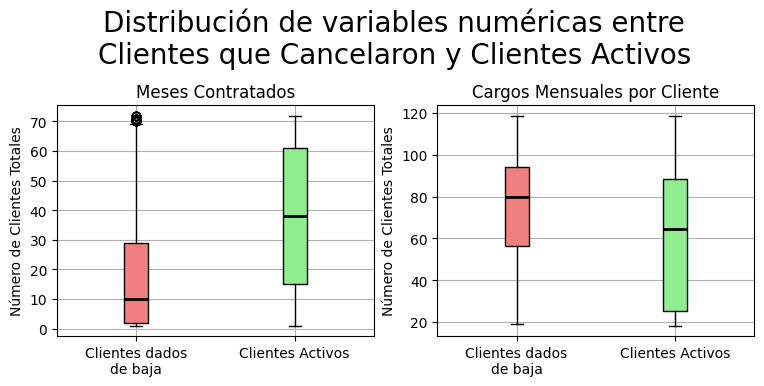

In [28]:
fig, axs = plt.subplots(1,2,figsize=(9,3))
fig.suptitle('Distribución de variables numéricas entre\nClientes que Cancelaron y Clientes Activos', fontsize=20, y=1.2)

colores = ['lightcoral', 'lightgreen']

#Gráfico de Caja de Meses Contratados
bp0 = axs[0].boxplot([evasores['Ternure'], continuan['Ternure']], tick_labels=['Clientes dados\nde baja', 'Clientes Activos'], patch_artist=True, medianprops=dict(color='black', linewidth=2))
axs[0].set_title('Meses Contratados')
axs[0].grid() #Coloca cuadrícula

for caja, color in zip(bp0['boxes'], colores):
    caja.set_facecolor(color)

#Gráfico de Caja de Cargos Mensuales
bp1 = axs[1].boxplot([evasores['Charges_Monthly'], continuan['Charges_Monthly']], tick_labels=['Clientes dados\nde baja', 'Clientes Activos'], patch_artist=True, medianprops=dict(color='black', linewidth=2))
axs[1].set_title('Cargos Mensuales por Cliente')
axs[1].grid() #Coloca cuadrícula

for caja, color in zip(bp1['boxes'], colores):
    caja.set_facecolor(color)

#Iteración para establecer los mismos Etiquetados
for ax in axs.flat:
  ax.set_xlabel('')
  ax.set_ylabel('Número de Clientes Totales')

#Almacenando el gráfico
fig.savefig('/content/Variables_numericas.png',
            transparent=False,dpi=300,bbox_inches='tight')

plt.show()

#🤖 Modelado Predictivo



##Separación de datos (Split)

In [29]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [30]:
from sklearn.model_selection import train_test_split

#Conjunto de prueba
X, X_test, y, y_test = train_test_split(X,y, test_size=0.02, stratify=y, random_state= 42)

#Conjunto de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X,y, stratify=y, random_state= 42)

###Verificar Desbalanceamiento

In [31]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
0,73.413313
1,26.586687


##Creación de Modelos

Modelo de Referencia

In [32]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
dummy.fit(X_train, y_train)
dummy.score(X_val, y_val) #Accuracy

0.7341845618107952

Modelo 1 — Regresión Logística

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000, class_weight='balanced') #Se aplica máscara para reducir riesgo de overfitting con datos reales
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_val)

print('Regresión Logística')
print(classification_report(y_val, y_pred_log_normal))

Regresión Logística
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1265
           1       0.51      0.77      0.62       458

    accuracy                           0.75      1723
   macro avg       0.71      0.75      0.71      1723
weighted avg       0.80      0.75      0.76      1723



Modelo 2 — KNearesNeighbor

In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_val)

print('KNearestNeighbor')
print(classification_report(y_val, y_pred_knn))

KNearestNeighbor
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1265
           1       0.54      0.48      0.51       458

    accuracy                           0.75      1723
   macro avg       0.68      0.67      0.67      1723
weighted avg       0.74      0.75      0.75      1723



Modelo 3 — Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print('Random Forest')
print(classification_report(y_val, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1265
           1       0.61      0.46      0.53       458

    accuracy                           0.78      1723
   macro avg       0.72      0.68      0.69      1723
weighted avg       0.76      0.78      0.77      1723



Modelo 4 — DecisionTreeClassifier

In [36]:
from sklearn.tree import DecisionTreeClassifier

dtc_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dtc_model.fit(X_train,y_train)

y_pred_dtc = dtc_model.predict(X_val)
#print(f'La exactitud del modelo con el conjunto de entrenamiento es: {modelo.score(X_train, y_train)}')
#print(f'La exactitud del modelo con el conjunto de validación es: {modelo.score(X_val, y_val)}')
print('DecisionTreeClassifier')
print(classification_report(y_val, y_pred_dtc))

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1265
           1       0.56      0.51      0.54       458

    accuracy                           0.76      1723
   macro avg       0.69      0.68      0.69      1723
weighted avg       0.76      0.76      0.76      1723



##Evaluación de los modelos

In [37]:
#Métricas
from sklearn.metrics import classification_report
#Matriz de Confusión
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

###Modelo 1 — Regresión Logística

In [38]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced') #Se aplica máscara para reducir riesgo de overfitting con datos reales
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_val)

print('Regresión Logística')
print(classification_report(y_val, y_pred_log))

Regresión Logística
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1265
           1       0.51      0.77      0.62       458

    accuracy                           0.75      1723
   macro avg       0.71      0.75      0.71      1723
weighted avg       0.80      0.75      0.76      1723



[[79 25]
 [ 9 28]]


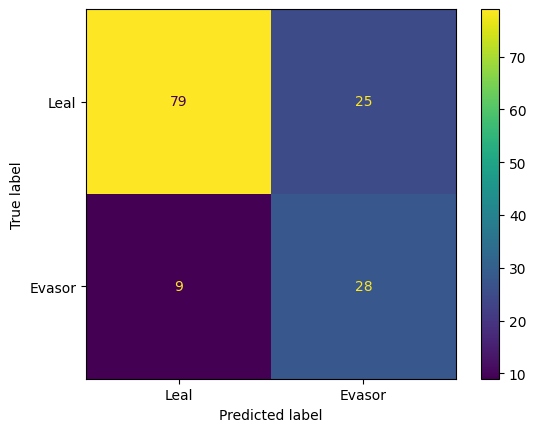

In [39]:
y_pred_log = log_model.predict(X_test)
matriz_confusion = confusion_matrix(y_test, y_pred=y_pred_log)
print(matriz_confusion)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Leal','Evasor'])
visualizacion.plot();

La regresión logística presentó un comportamiento estable entre los conjuntos de validación y prueba, sin evidencia de sobreajuste ni subajuste. El modelo generaliza adecuadamente y mantiene un buen recall en la clase minoritaria, lo cual es relevante en el problema de evasión de clientes.

### Modelo 2 — KNearesNeighbor

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_val)

print('KNearestNeighbor')
print(classification_report(y_val, y_pred_knn))

KNearestNeighbor
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1265
           1       0.54      0.48      0.51       458

    accuracy                           0.75      1723
   macro avg       0.68      0.67      0.67      1723
weighted avg       0.74      0.75      0.75      1723



[[90 14]
 [21 16]]


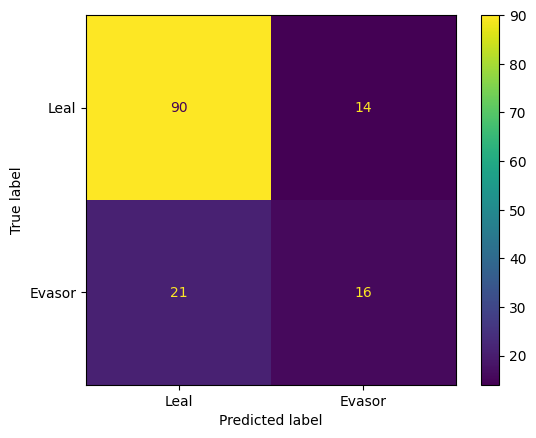

In [41]:
y_pred_knn = knn_model.predict(X_test)
matriz_confusion = confusion_matrix(y_test, y_pred=y_pred_knn)
print(matriz_confusion)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Leal','Evasor'])
visualizacion.plot();

El modelo K-Nearest Neighbors no presenta evidencia de sobreajuste, dado que el desempeño se mantiene estable entre validación y prueba. Sin embargo, hay underfitting leve para la clase 1.

Disminuyendo la K y optimizando los hiperparámetros con GridSearch:

In [42]:
from sklearn.model_selection import GridSearchCV
import numpy as np

# Espacio de búsqueda
param_grid = {
    'n_neighbors': [3,5,7,9,11,15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Optimizar priorizando recall (clase 1)
grid = GridSearchCV(
    knn_model,
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


In [43]:
knn_model = KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='uniform')
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_val)

print('KNearestNeighbor')
print(classification_report(y_val, y_pred_knn))

KNearestNeighbor
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1265
           1       0.54      0.53      0.53       458

    accuracy                           0.76      1723
   macro avg       0.69      0.68      0.68      1723
weighted avg       0.75      0.76      0.75      1723



[[88 16]
 [20 17]]


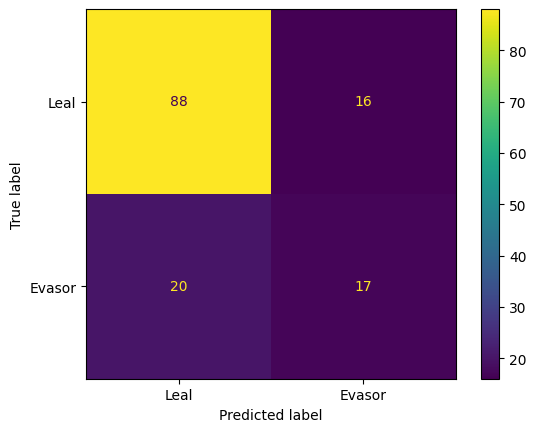

In [44]:
y_pred_knn = knn_model.predict(X_test)
matriz_confusion = confusion_matrix(y_test, y_pred=y_pred_knn)
print(matriz_confusion)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Leal','Evasor'])
visualizacion.plot();

Sigue habiendo un leve Underfitting para la clase 1.

Validación Cruzada

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [46]:
#Función para crear informe de métricas

def informe_metricas(resultados):
    for metrica in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
        media = resultados[metrica].mean()
        desvio_estandar = resultados[metrica].std()
        print(f'Intervalo de confianza({metrica}): [{media-2*desvio_estandar}, {min(media+2*desvio_estandar, 1.0)}]')

In [47]:
knn_model = KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='uniform')

skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)
cv_knnModel = cross_validate(knn_model, X, y, cv=skf, scoring = ['accuracy','recall', 'precision', 'f1'])
cv_knnModel

{'fit_time': array([0.00288415, 0.00228286, 0.00290656, 0.00245023, 0.0038259 ]),
 'score_time': array([0.12431121, 0.12866306, 0.12387729, 0.13215184, 0.12312865]),
 'test_accuracy': array([0.75924583, 0.75181422, 0.76269956, 0.74963716, 0.7670537 ]),
 'test_recall': array([0.49591281, 0.54644809, 0.54918033, 0.52459016, 0.4986376 ]),
 'test_precision': array([0.55319149, 0.53191489, 0.55371901, 0.52892562, 0.571875  ]),
 'test_f1': array([0.52298851, 0.53908356, 0.55144033, 0.52674897, 0.53275109])}

In [48]:
informe_metricas(cv_knnModel)

Intervalo de confianza(test_accuracy): [0.7450128499954654, 0.7711673398941392]
Intervalo de confianza(test_recall): [0.47765494288865984, 0.5682526522930678]
Intervalo de confianza(test_precision): [0.5162744973915713, 0.5795759070395875]
Intervalo de confianza(test_f1): [0.5145309618129161, 0.554674020512359]


Se confirma un subajuste estructural debido a que el recall es consistentemente < 0.60 y F1 no supera 0.58. Es decir, no logra capturar bien el patrón de churn.

Por ello podríamos ajustarlo balanceando los datos de entrenamaiento usando SMOTE en un pipeline:

In [49]:
from imblearn.pipeline import Pipeline as imbpipeline

In [50]:
from imblearn.over_sampling import SMOTE
pipeline_knnOver = imbpipeline([('oversample', SMOTE()),('k_nearest_neighbor', knn_model)])
cv_knnOver = cross_validate(pipeline_knnOver,X,y,cv=skf, scoring=['accuracy','recall', 'precision', 'f1'])
informe_metricas(cv_knnOver)

Intervalo de confianza(test_accuracy): [0.6963119948283625, 0.7278629873583042]
Intervalo de confianza(test_recall): [0.6613904996051478, 0.7010668789329919]
Intervalo de confianza(test_precision): [0.45169258860312045, 0.4913966432295668]
Intervalo de confianza(test_f1): [0.5439621904267964, 0.5704383363700489]


La incorporación de SMOTE dentro del proceso de validación cruzada incrementó significativamente el recall de la clase minoritaria, mejorando la capacidad del modelo para identificar clientes evasores. No se observó evidencia de sobreajuste, dado que las métricas presentan baja variabilidad entre particiones. Hubo disminución en precision y accuracy.

### Modelo 3 — Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print('Random Forest')
print(classification_report(y_val, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1265
           1       0.61      0.46      0.53       458

    accuracy                           0.78      1723
   macro avg       0.72      0.68      0.69      1723
weighted avg       0.76      0.78      0.77      1723



[[93 11]
 [17 20]]


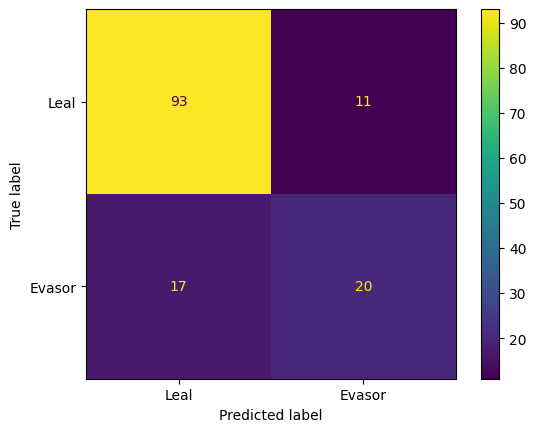

In [52]:
y_pred_rf = rf_model.predict(X_test)
matriz_confusion = confusion_matrix(y_test, y_pred=y_pred_rf)
print(matriz_confusion)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Leal','Evasor'])
visualizacion.plot();

El modelo Random Forest no presenta evidencia de sobreajuste, dado que el rendimiento se mantiene estable e incluso mejora ligeramente en el conjunto de prueba. Sin embargo, hay un ligero subajuste, ya que muestra una capacidad limitada para identificar la clase minoritaria obteniendo un recall bajo para clientes evasores.

Aplicando una máscara class_weigh= 'balanced':

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight= 'balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print('Random Forest con class_weigh= "balanced"')
print(classification_report(y_val, y_pred_rf))

Random Forest con class_weigh= "balanced"
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1265
           1       0.61      0.47      0.53       458

    accuracy                           0.78      1723
   macro avg       0.72      0.68      0.69      1723
weighted avg       0.77      0.78      0.77      1723



[[92 12]
 [15 22]]


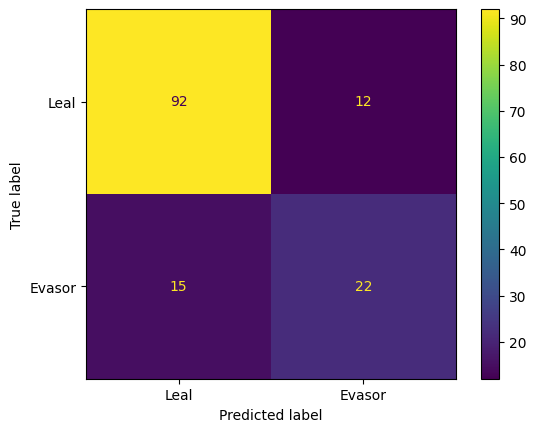

In [54]:
y_pred_rf = rf_model.predict(X_test)
matriz_confusion = confusion_matrix(y_test, y_pred=y_pred_rf)
print(matriz_confusion)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Leal','Evasor'])
visualizacion.plot();

La incorporación de class_weight='balanced' en el modelo Random Forest no produjo cambios sustanciales en el desempeño. Continua presencia de subajuste leve pero no es estructural.

Haremos modificación de hiperparámetros:

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring='recall',  # importante si churn es prioridad
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros:", grid_rf.best_params_)

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [56]:
rf_model = RandomForestClassifier(max_depth= 5, min_samples_leaf=1, min_samples_split=5, n_estimators=100, class_weight= 'balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print('Random Forest con modificación de hiperparámetros')
print(classification_report(y_val, y_pred_rf))

Random Forest con modificación de hiperparámetros
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1265
           1       0.51      0.78      0.62       458

    accuracy                           0.75      1723
   macro avg       0.71      0.76      0.71      1723
weighted avg       0.80      0.75      0.76      1723



[[75 29]
 [ 7 30]]


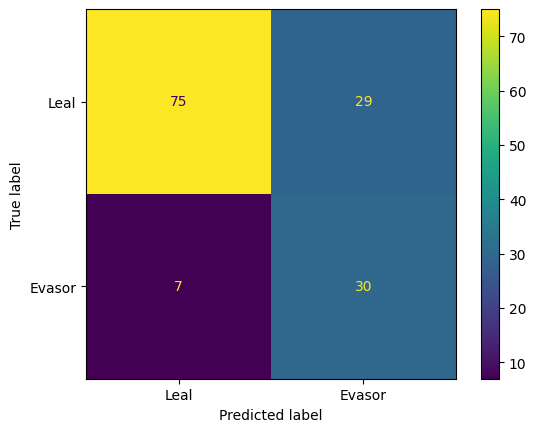

In [57]:
y_pred_rf = rf_model.predict(X_test)
matriz_confusion = confusion_matrix(y_test, y_pred=y_pred_rf)
print(matriz_confusion)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Leal','Evasor'])
visualizacion.plot();

Ahora sí hay una buena generalización con una alta sensibilidad a evasión y un buen equilibrio global.

###Modelo 4 — DecisionTreeClassifier

In [58]:
dtc_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dtc_model.fit(X_train,y_train)

y_pred_dtc = dtc_model.predict(X_val)

print('DecisionTreeClassifier')
print(classification_report(y_val, y_pred_dtc))

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1265
           1       0.56      0.51      0.54       458

    accuracy                           0.76      1723
   macro avg       0.69      0.68      0.69      1723
weighted avg       0.76      0.76      0.76      1723



[[90 14]
 [19 18]]


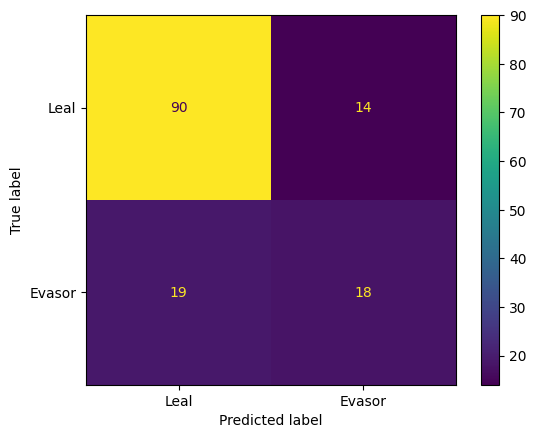

In [59]:
y_pred_dtc = dtc_model.predict(X_test)
matriz_confusion = confusion_matrix(y_test, y_pred=y_pred_dtc)
print(matriz_confusion)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Leal','Evasor'])
visualizacion.plot();

El árbol de decisión no presenta subajuste moderadodebidoa que Recall es consistentemente bajo (~0.50) y F1 es moderado. No logra capturar bien la clase minoritaria. Sí está separando bien la clase mayoritaria, pero no modelando con suficiente sensibilidad el churn.

Por ello realizaré una optmización de parámetros:

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dtc_model = DecisionTreeClassifier(max_depth=10, random_state=42)

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    dtc_model,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Mejores parámetros:", grid_dt.best_params_)

Mejores parámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [61]:
dtc_model = DecisionTreeClassifier(max_depth=5, criterion='gini', min_samples_leaf=1, min_samples_split=2, random_state=42)
dtc_model.fit(X_train,y_train)

y_pred_dtc = dtc_model.predict(X_val)

print('DecisionTreeClassifier con modificación de Hiperparámetros')
print(classification_report(y_val, y_pred_dtc))

DecisionTreeClassifier con modificación de Hiperparámetros
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1265
           1       0.60      0.60      0.60       458

    accuracy                           0.79      1723
   macro avg       0.73      0.73      0.73      1723
weighted avg       0.79      0.79      0.79      1723



[[86 18]
 [13 24]]


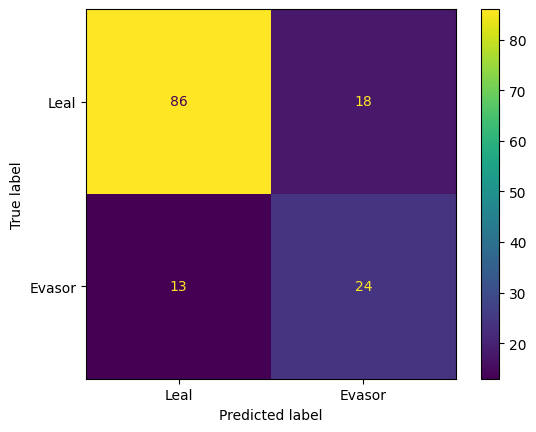

In [62]:
y_pred_dtc = dtc_model.predict(X_test)
matriz_confusion = confusion_matrix(y_test, y_pred=y_pred_dtc)
print(matriz_confusion)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Leal','Evasor'])
visualizacion.plot();

Ahora sí se tiene un mejor ajuste.

 # Comparación de Modelos - Detección de Evasión (Churn)

| Modelo                          | Accuracy | Recall | Precision | F1-score |
|---------------------------------|----------|--------|-----------|----------|
| Regresión Logística (balanced)  | 0.75     | 0.77   | 0.51      | 0.62     |
| KNN                             | 0.75     | 0.48   | 0.54      | 0.51     |
| KNN (Optimizado)	              | 0.76     | 0.52   |	0.55	    | 0.53     |
| KNN + SMOTE                     | 0.70     | 0.73   | 0.46      | 0.57     |
| Random Forest (balanced)        | 0.78     | 0.47   | 0.61      | 0.53     |
| Random Forest (Optimizado)      | 0.75     | 0.78   | 0.51      | 0.62     |
| Decision Tree                   | 0.76     | 0.51   | 0.56      | 0.54     |
| Decision Tree (Optimizado)      | 0.79     | 0.60   | 0.60      | 0.60     |




🥇 Random Forest Optimizado

🥈 Regressión Logística

Tras evaluar distintos modelos de clasificación, se observó que los modelos con mejor desempeño para la detección de clientes evasores fueron **Random Forest optimizado** y **Regresión Logística con balanceo de clases**. Sin embargo, el **Decision Tree optimizado** presentó el mejor equilibrio entre precisión y recall, obteniendo el mayor valor de F1-score entre los modelos evaluados. Esto sugiere que el árbol de decisión logra capturar adecuadamente los patrones asociados a la evasión sin generar un exceso de falsos positivos

#📋 Interpretación y Conclusiones

##Análisis de la Importancia de las Variables

In [63]:
#Regresión Logística
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)
coeficientes

,Variable,Coeficiente
13,Contract_Monthly,0.457153
8,Paperless_Billing,0.355925
12,Internet_FiberOptic,0.306991
0,Senior_Citizen,0.211414
17,Payment_Electronic_Check,0.210601
11,Internet_DSL,0.064095
1,Partner,0.039948
9,Charges_Monthly,0.015548
6,Device_Protection,-0.013165
3,Ternure,-0.029326


Aquellas variables con coeficiente positivo aumentan el riesgo de cancelación según el modelo de Regresión Logística.

In [64]:
#K-Nearest Neighbors
from sklearn.inspection import permutation_importance

pipeline_knnOver.fit(X_train,y_train) #Entrenar Pipeline

result = permutation_importance(
    pipeline_knnOver, #Pipeline entrenado
    X_val,
    y_val,
    scoring='recall',
    n_repeats=10,
    random_state=42
)

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": result.importances_mean
}).sort_values(by="Importancia", ascending=False)

importancias

,Variable,Importancia
3,Ternure,0.146070
9,Charges_Monthly,0.081004
2,Dependents,0.008734
1,Partner,0.006987
4,Online_Security,0.005677
8,Paperless_Billing,0.004585
0,Senior_Citizen,0.003712
12,Internet_FiberOptic,0.003057
11,Internet_DSL,0.002620
6,Device_Protection,0.001310


El análisis de importancia mediante Permutation Importance mostró que las variables más determinantes para el modelo KNN (con valor positivo lejano a 0) son la antigüedad del cliente (Tenure) y los cargos mensuales (Charges_Monthly). Estas variables estructuran el espacio de proximidad entre clientes, influyendo directamente en la clasificación basada en vecinos más cercanos.

In [65]:
#Random Forest
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)
importancias

,Variable,Importancia
13,Contract_Monthly,0.238523
3,Ternure,0.180566
15,Contract_TwoYear,0.112050
12,Internet_FiberOptic,0.091264
9,Charges_Monthly,0.080184
17,Payment_Electronic_Check,0.074004
10,Internet_Service,0.066152
14,Contract_OneYear,0.038442
4,Online_Security,0.027977
11,Internet_DSL,0.020838


El modelo Random Forest identificó que el contrato mensuale y la antigüedad del cliente son los factores más relevantes en la predicción de cancelación. Estas variables explican más del 40% de la importancia total del modelo. El tipo de contrato por dos años también muestra un impacto significativo, mientras que variables demográficas presentan menor contribución relativa.

In [66]:
#Decision Tree Classifier
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": dtc_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importancias

,Variable,Importancia
13,Contract_Monthly,0.493492
3,Ternure,0.210854
12,Internet_FiberOptic,0.150280
9,Charges_Monthly,0.053733
10,Internet_Service,0.038419
17,Payment_Electronic_Check,0.032646
15,Contract_TwoYear,0.011308
7,Tech_Support,0.006089
18,Payment_Credit_Card,0.002681
0,Senior_Citizen,0.000497


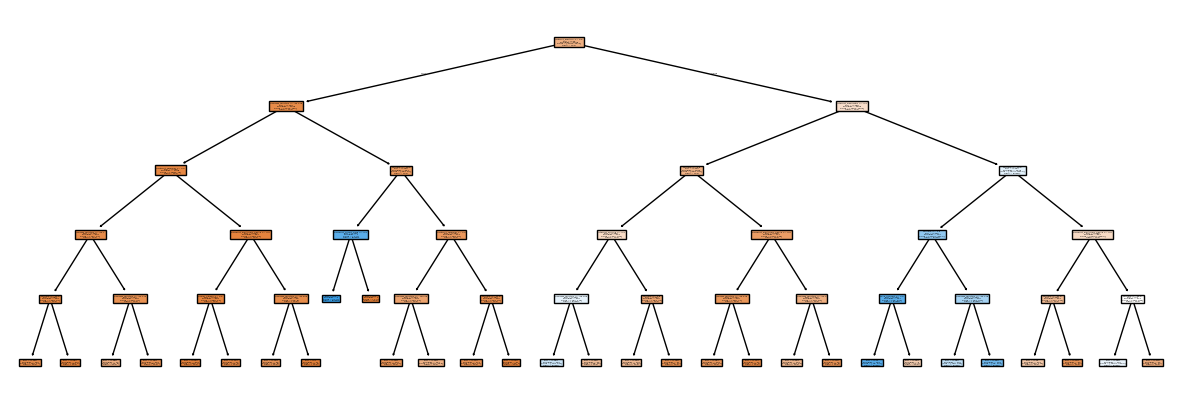

In [70]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plot_tree(dtc_model, feature_names=X.columns, class_names=["Leal","Evasor"], filled=True)
plt.show()

El modelo Decision Tree Classifier identificó que el contrato mensual, la antigüedad del cliente y la instalación de fibra óptica son los factores más relevantes en la predicción de cancelación. Estas variables explican más del 85% de la importancia total del modelo.

##Conclusión

#Informe de análisis de variables relevantes en la cancelación de clientes
##1. Introducción

El objetivo de este análisis fue **identificar los factores que influyen en la cancelación de clientes** mediante la aplicación de distintos modelos de clasificación. Para ello se evaluaron cuatro algoritmos de aprendizaje supervisado:

* Logistic Regression

* K-Nearest Neighbors

* Random Forest

* Decision Tree

Cada modelo permite **analizar la importancia de las variables desde diferentes perspectivas**, lo que ayuda a identificar patrones robustos asociados a la evasión de clientes.

El análisis se centró en determinar:

* qué variables **aumentan la probabilidad de cancelación**

* qué variables **favorecen la permanencia del cliente**

* qué factores son **consistentes entre distintos modelos**
-------
##2. Resultados del análisis de importancia de variables
###2.1 Resultados de Regresión Logística

En este modelo, los coeficientes indican cómo influye cada variable en la probabilidad de cancelación:

coeficientes **positivos** → **aumentan la probabilidad de churn**

coeficientes **negativos** → **reducen la probabilidad de churn**

**Variables que aumentan la cancelación**

Los factores con mayor impacto positivo fueron:

1. Contract_Monthly

2. Paperless_Billing

3. Internet_FiberOptic

4. Senior_Citizen

5. Payment_Electronic_Check

Interpretación:

Los clientes con **contratos mensuales** presentan una mayor probabilidad de cancelar, lo cual sugiere que **la ausencia de compromiso contractual favorece la rotación**.

Los clientes con **fibra óptica** presentan mayor churn, posiblemente relacionado con **expectativas de servicio más altas o mayor competencia entre proveedores**.

Los pagos mediante **cheque electrónico** y el uso de **facturación digital** también se asocian con mayor cancelación.

**Variables que reducen la cancelación**

Las variables con coeficientes negativos más importantes fueron:

* Contract_TwoYear

* Internet_Service

* Online_Security

* Tech_Support

Interpretación:

Los clientes que cuentan con:

* contratos de **mayor duración**

* servicios adicionales de **seguridad o soporte**

presentan mayor **fidelidad al servicio**.

-------
###2.2 Resultados del modelo KNN

En el modelo KNN la importancia se obtuvo mediante **permutation importance**, lo que mide cuánto empeora el modelo al alterar una variable.

Las variables más relevantes fueron:

1. Tenure

2. Charges_Monthly

3. Dependents

4. Partner

5. Online_Security

Interpretación:

* **Tenure** (tiempo como cliente) es el factor más influyente.

* Los clientes con **mayor antigüedad** tienden a **cancelar menos**.

* El **monto mensual** del servicio también influye significativamente en la decisión de permanencia.

Esto sugiere que **la relación a largo plazo con la empresa reduce la probabilidad de cancelación**.

---
###2.3 Resultados del modelo Random Forest

El modelo Random Forest calcula la importancia de las variables en función de la **reducción de impureza en los árboles**.

Las variables más importantes fueron:

1. Contract_Monthly

2. Tenure

3. Contract_TwoYear

4. Internet_FiberOptic

5. Charges_Monthly

6. Payment_Electronic_Check

Interpretación:

Este modelo confirma varios patrones observados en los modelos anteriores:

* El **tipo de contrato** es el principal factor asociado al churn.

* La **antigüedad del cliente** tiene un impacto importante en la permanencia.

* El **tipo de conexión a internet** también influye en la cancelación.

---
###2.4 Resultados del modelo Decision Tree Classifier

En el árbol de decisión, la importancia de las variables depende de **las divisiones que generan mayor ganancia de información**.

Las variables más influyentes fueron:

1. Contract_Monthly

2. Tenure

3. Internet_FiberOptic

4. Charges_Monthly

5. Internet_Service

6. Payment_Electronic_Check

Interpretación:

El modelo muestra que:

* El **tipo de contrato** domina las decisiones del árbol.

* La **antigüedad del cliente** es el segundo factor más determinante.

* El **tipo de conexión a internet** también influye considerablemente.

---
##3. Factores clave asociados a la cancelación

Al comparar los resultados de los cuatro modelos, se identificaron **patrones consistentes**.

###**Factores que aumentan la probabilidad de cancelación**

Los principales factores de riesgo son:

1. Contratos mensuales

Los clientes sin compromiso contractual tienen mayor probabilidad de abandonar el servicio.

2. Baja antigüedad del cliente

Los clientes recientes presentan mayor riesgo de cancelación.

3. Conexión de fibra óptica

Puede indicar expectativas más altas o mayor competencia.

4. Altos cargos mensuales

Los clientes con tarifas más elevadas muestran mayor tendencia a cancelar.

5. Pagos mediante cheque electrónico

Este método de pago aparece repetidamente asociado al churn.

---
###**Factores que reducen la cancelación**

Los factores asociados a mayor fidelización incluyen:

1. Contratos de largo plazo

Tanto contratos de un año como contratos de dos años.

2. Servicios adicionales

Servicios como soporte técnico y seguridad en línea aumentan la retención.

3. Mayor antigüedad del cliente

Los clientes con mayor tiempo en la empresa tienen menor probabilidad de cancelar.

---
##4. Estrategias de retención basadas en los resultados

A partir del análisis de los modelos, se pueden proponer diversas estrategias para **reducir la tasa de cancelación**.

###4.1 Incentivar contratos de largo plazo

Dado que los contratos mensuales presentan mayor churn, se recomienda:

* ofrecer descuentos por **contratos anuales**

* ofrecer beneficios exclusivos para **contratos de dos años**

Esto puede aumentar la fidelización.

---
###4.2 Estrategias para nuevos clientes

Los clientes con menor antigüedad presentan mayor riesgo de abandono.

Se recomienda:

* implementar **programas de bienvenida**

* ofrecer **soporte personalizado durante los primeros meses**

* aplicar **descuentos iniciales**

---
###4.3 Optimización del precio del servicio

Los cargos mensuales elevados se asocian con mayor cancelación.

Se recomienda:

* ofrecer paquetes personalizados

* implementar descuentos por fidelidad

* revisar la competitividad de los precios.

---
###4.4 Promoción de servicios complementarios

Servicios como **seguridad en línea** y **soporte técnico** reducen la probabilidad de cancelación.

Se recomienda:

* promover estos servicios **mediante bundles**

* ofrecerlos como **beneficio en planes premium**

---
##5. Conclusión

El análisis realizado mediante distintos modelos de clasificación permitió identificar los principales factores asociados a la cancelación de clientes.

Los resultados muestran que los factores más influyentes son:

* el tipo de contrato

* la antigüedad del cliente

* el tipo de conexión a internet

* el costo mensual del servicio

* el método de pago

Entre estos factores, el **contrato mensual** y la **baja antigüedad del cliente** se identifican como los indicadores más consistentes de riesgo de cancelación.

Las estrategias de retención deberían centrarse en:

* incentivar contratos de mayor duración

* mejorar la experiencia de clientes nuevos

* optimizar los planes de servicio y precios

* promover servicios adicionales de valor

La aplicación de estas estrategias puede contribuir a **reducir la tasa de evasión** y **mejorar la fidelización de los clientes**.